In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('train.csv')
data

,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,...,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,...,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0
1,1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,...,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0
2,2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,...,1.0,14.0,NaN,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0
3,3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,...,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0
4,4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,...,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199995,1199995,36.0,Female,27316.0,Married,0.0,Master's,Unemployed,13.772907,Urban,...,NaN,5.0,372.0,3.0,2023-05-03 15:21:39.257696,Poor,No,Daily,Apartment,1303.0
1199996,1199996,54.0,Male,35786.0,Divorced,NaN,Master's,Self-Employed,11.483482,Rural,...,NaN,10.0,597.0,4.0,2022-09-10 15:21:39.134960,Poor,No,Weekly,Apartment,821.0
1199997,1199997,19.0,Male,51884.0,Divorced,0.0,Master's,NaN,14.724469,Suburban,...,0.0,19.0,NaN,6.0,2021-05-25 15:21:39.106582,Good,No,Monthly,Condo,371.0
1199998,1199998,55.0,Male,NaN,Single,1.0,PhD,NaN,18.547381,Suburban,...,1.0,7.0,407.0,4.0,2021-09-19 15:21:39.190215,Poor,No,Daily,Apartment,596.0


drop:
1. id
2. customer feedback
3. Previous Claims
4. Policy start date

NaN cleanup strategy:
1. Direct dropnan on all NaN in age because total data only 1.5% from the whole population and distribution would still be intact
2. Direct dropnan on all NaN in Annual Income because total data loss combined with Age only 5.2% from the whole population
3. In marital status, we will add One Hot Encoding styleso divided by 4 parts: Unknown, Single, Married, Divorced
4. In Occupation status, we will add One Hot Encoding styleso divided by 4 parts: Unknown, Self-Employed, Unemployed, Employed
5. Drop Column Number of Dependents, plot the hexbin and you'll see that all data concentrated between 2000-3000. With this tight separation, it's not helping ML model due to lack of variances

In [3]:
data.drop(columns=['id', 'Customer Feedback', 'Previous Claims', 'Policy Start Date'], inplace=True)
data

,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Vehicle Age,Credit Score,Insurance Duration,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,Premium,17.0,372.0,5.0,No,Weekly,House,2869.0
1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,Comprehensive,12.0,694.0,2.0,Yes,Monthly,House,1483.0
2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,Premium,14.0,NaN,3.0,Yes,Weekly,House,567.0
3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,Basic,0.0,367.0,1.0,Yes,Daily,Apartment,765.0
4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,Premium,8.0,598.0,4.0,Yes,Weekly,House,2022.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199995,36.0,Female,27316.0,Married,0.0,Master's,Unemployed,13.772907,Urban,Premium,5.0,372.0,3.0,No,Daily,Apartment,1303.0
1199996,54.0,Male,35786.0,Divorced,NaN,Master's,Self-Employed,11.483482,Rural,Comprehensive,10.0,597.0,4.0,No,Weekly,Apartment,821.0
1199997,19.0,Male,51884.0,Divorced,0.0,Master's,NaN,14.724469,Suburban,Basic,19.0,NaN,6.0,No,Monthly,Condo,371.0
1199998,55.0,Male,NaN,Single,1.0,PhD,NaN,18.547381,Suburban,Premium,7.0,407.0,4.0,No,Daily,Apartment,596.0


In [8]:
data.isnull().sum()

Age                              0
Gender                           0
Annual Income                    0
Education Level                  0
Health Score                 70618
Location                         0
Policy Type                      0
Vehicle Age                      0
Credit Score                132427
Insurance Duration               0
Smoking Status                   0
Exercise Frequency               0
Property Type                    0
Premium Amount                   0
Marital Status_Divorced          0
Marital Status_Married           0
Marital Status_Single            0
Marital Status_Unknown           0
Occupation_Employed              0
Occupation_Self-Employed         0
Occupation_Unemployed            0
Occupation_Unknown               0
dtype: int64

In [10]:
b = data.loc[(data['Age'].isnull()) |
             (data['Annual Income'].isnull()), :]
b

,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Vehicle Age,Credit Score,Insurance Duration,Smoking Status,Exercise Frequency,Property Type,Premium Amount
22,22.0,Male,NaN,Divorced,4.0,PhD,NaN,25.583790,Urban,Comprehensive,5.0,773.0,5.0,Yes,Monthly,House,202.0
36,41.0,Female,NaN,Married,3.0,PhD,Self-Employed,14.001630,Urban,Comprehensive,15.0,589.0,6.0,No,Rarely,House,250.0
67,45.0,Male,NaN,Married,3.0,High School,Self-Employed,17.988631,Suburban,Comprehensive,18.0,375.0,9.0,Yes,Rarely,House,829.0
83,NaN,Male,645.0,Single,3.0,PhD,Employed,30.766284,Urban,Comprehensive,18.0,319.0,4.0,No,Weekly,House,934.0
86,37.0,Male,NaN,Single,1.0,Bachelor's,NaN,13.038269,Suburban,Comprehensive,6.0,562.0,2.0,No,Weekly,House,61.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199894,30.0,Female,NaN,Single,3.0,Bachelor's,Unemployed,29.844105,Urban,Basic,7.0,400.0,8.0,Yes,Rarely,House,1087.0
1199897,NaN,Male,27306.0,Divorced,NaN,Bachelor's,Self-Employed,15.726853,Suburban,Comprehensive,7.0,509.0,3.0,No,Weekly,Condo,1625.0
1199925,45.0,Male,NaN,Married,0.0,High School,Self-Employed,51.402797,Urban,Basic,2.0,NaN,8.0,No,Rarely,Condo,1526.0
1199998,55.0,Male,NaN,Single,1.0,PhD,NaN,18.547381,Suburban,Premium,7.0,407.0,4.0,No,Daily,Apartment,596.0


C:\Users\anton\AppData\Local\Temp\ipykernel_29032\3609432827.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c.dropna(inplace=True)


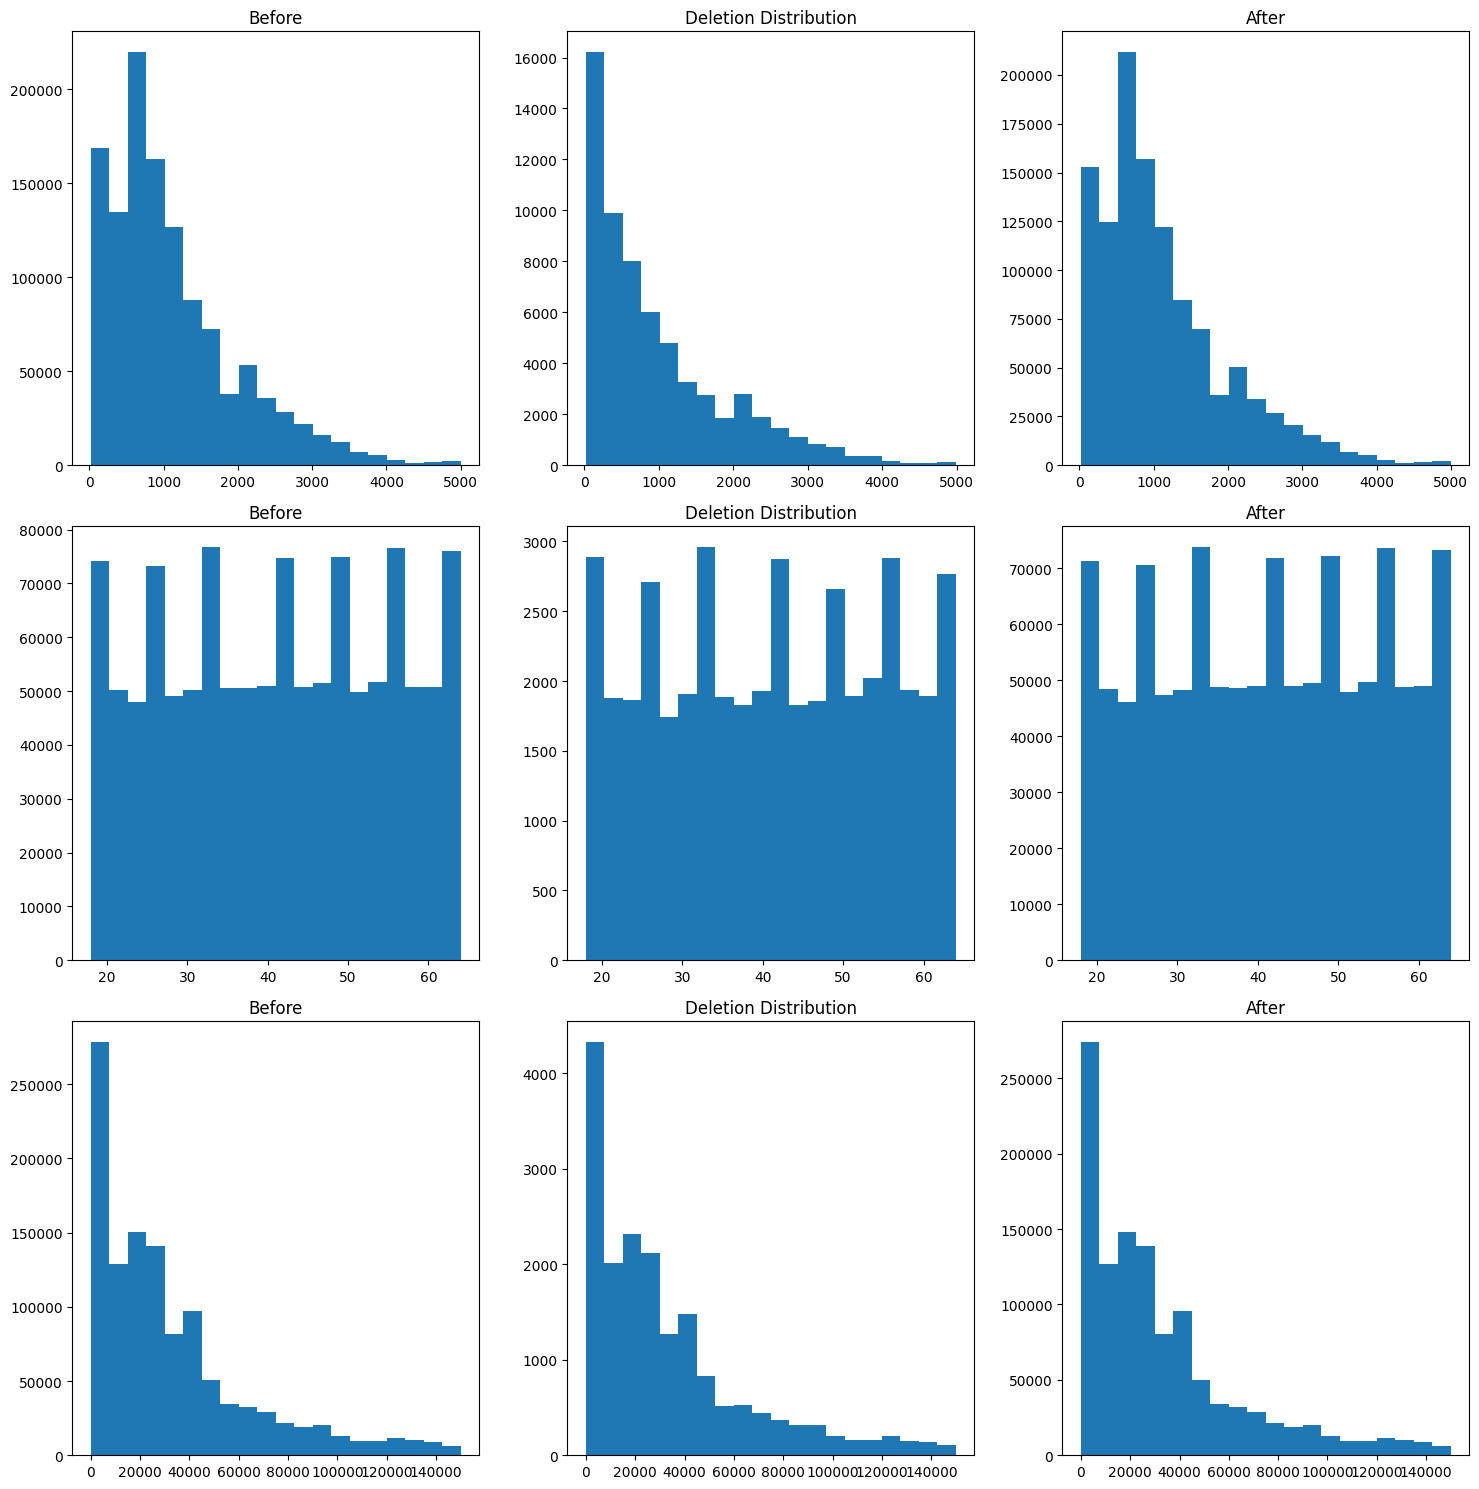

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,15))
plt.subplot(331)
plt.hist(x=data['Premium Amount'].values, bins=20)
plt.title('Before')

plt.subplot(332)
plt.hist(x=b['Premium Amount'].values, bins=20)
plt.title('Deletion Distribution')

c = data[['Age', 'Annual Income', 'Premium Amount']]
c.dropna(inplace=True)
plt.subplot(333)
plt.hist(x=c[['Premium Amount']].values, bins=20)
plt.title('After')

plt.subplot(334)
plt.hist(x=data['Age'].values, bins=20)
plt.title('Before')

plt.subplot(335)
plt.hist(x=b['Age'].values, bins=20)
plt.title('Deletion Distribution')

plt.subplot(336)
plt.hist(x=c[['Age']].values, bins=20)
plt.title('After')

plt.subplot(337)
plt.hist(x=data['Annual Income'].values, bins=20)
plt.title('Before')

plt.subplot(338)
plt.hist(x=b['Annual Income'].values, bins=20)
plt.title('Deletion Distribution')

plt.subplot(339)
plt.hist(x=c[['Annual Income']].values, bins=20)
plt.title('After')

plt.tight_layout()
plt.show()

REMARKS: After age and Annual Incme deletion the distribution still intact

In [5]:
data = data.dropna(subset=['Age', 'Annual Income', 'Vehicle Age', 'Insurance Duration'])
data.drop(columns='Number of Dependents', inplace=True)
data

C:\Users\anton\AppData\Local\Temp\ipykernel_10156\2463509942.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(columns='Number of Dependents', inplace=True)


,Age,Gender,Annual Income,Marital Status,Education Level,Occupation,Health Score,Location,Policy Type,Vehicle Age,Credit Score,Insurance Duration,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,19.0,Female,10049.0,Married,Bachelor's,Self-Employed,22.598761,Urban,Premium,17.0,372.0,5.0,No,Weekly,House,2869.0
1,39.0,Female,31678.0,Divorced,Master's,NaN,15.569731,Rural,Comprehensive,12.0,694.0,2.0,Yes,Monthly,House,1483.0
2,23.0,Male,25602.0,Divorced,High School,Self-Employed,47.177549,Suburban,Premium,14.0,NaN,3.0,Yes,Weekly,House,567.0
3,21.0,Male,141855.0,Married,Bachelor's,NaN,10.938144,Rural,Basic,0.0,367.0,1.0,Yes,Daily,Apartment,765.0
4,21.0,Male,39651.0,Single,Bachelor's,Self-Employed,20.376094,Rural,Premium,8.0,598.0,4.0,Yes,Weekly,House,2022.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199993,38.0,Male,1607.0,Married,High School,NaN,18.552314,Suburban,Comprehensive,12.0,469.0,2.0,No,Rarely,House,1027.0
1199994,34.0,Male,23456.0,Single,Master's,Self-Employed,14.783439,Rural,Basic,12.0,548.0,9.0,No,Monthly,Apartment,1584.0
1199995,36.0,Female,27316.0,Married,Master's,Unemployed,13.772907,Urban,Premium,5.0,372.0,3.0,No,Daily,Apartment,1303.0
1199996,54.0,Male,35786.0,Divorced,Master's,Self-Employed,11.483482,Rural,Comprehensive,10.0,597.0,4.0,No,Weekly,Apartment,821.0


In [6]:
data['Marital Status'] = data['Marital Status'].fillna(value='Unknown')
data['Occupation'] = data['Occupation'].fillna(value='Unknown')
data

C:\Users\anton\AppData\Local\Temp\ipykernel_10156\4107185261.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Marital Status'] = data['Marital Status'].fillna(value='Unknown')
C:\Users\anton\AppData\Local\Temp\ipykernel_10156\4107185261.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Occupation'] = data['Occupation'].fillna(value='Unknown')


,Age,Gender,Annual Income,Marital Status,Education Level,Occupation,Health Score,Location,Policy Type,Vehicle Age,Credit Score,Insurance Duration,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,19.0,Female,10049.0,Married,Bachelor's,Self-Employed,22.598761,Urban,Premium,17.0,372.0,5.0,No,Weekly,House,2869.0
1,39.0,Female,31678.0,Divorced,Master's,Unknown,15.569731,Rural,Comprehensive,12.0,694.0,2.0,Yes,Monthly,House,1483.0
2,23.0,Male,25602.0,Divorced,High School,Self-Employed,47.177549,Suburban,Premium,14.0,NaN,3.0,Yes,Weekly,House,567.0
3,21.0,Male,141855.0,Married,Bachelor's,Unknown,10.938144,Rural,Basic,0.0,367.0,1.0,Yes,Daily,Apartment,765.0
4,21.0,Male,39651.0,Single,Bachelor's,Self-Employed,20.376094,Rural,Premium,8.0,598.0,4.0,Yes,Weekly,House,2022.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199993,38.0,Male,1607.0,Married,High School,Unknown,18.552314,Suburban,Comprehensive,12.0,469.0,2.0,No,Rarely,House,1027.0
1199994,34.0,Male,23456.0,Single,Master's,Self-Employed,14.783439,Rural,Basic,12.0,548.0,9.0,No,Monthly,Apartment,1584.0
1199995,36.0,Female,27316.0,Married,Master's,Unemployed,13.772907,Urban,Premium,5.0,372.0,3.0,No,Daily,Apartment,1303.0
1199996,54.0,Male,35786.0,Divorced,Master's,Self-Employed,11.483482,Rural,Comprehensive,10.0,597.0,4.0,No,Weekly,Apartment,821.0


In [7]:
data = pd.get_dummies(data=data, columns=['Marital Status', 'Occupation'])
data

,Age,Gender,Annual Income,Education Level,Health Score,Location,Policy Type,Vehicle Age,Credit Score,Insurance Duration,...,Property Type,Premium Amount,Marital Status_Divorced,Marital Status_Married,Marital Status_Single,Marital Status_Unknown,Occupation_Employed,Occupation_Self-Employed,Occupation_Unemployed,Occupation_Unknown
0,19.0,Female,10049.0,Bachelor's,22.598761,Urban,Premium,17.0,372.0,5.0,...,House,2869.0,False,True,False,False,False,True,False,False
1,39.0,Female,31678.0,Master's,15.569731,Rural,Comprehensive,12.0,694.0,2.0,...,House,1483.0,True,False,False,False,False,False,False,True
2,23.0,Male,25602.0,High School,47.177549,Suburban,Premium,14.0,NaN,3.0,...,House,567.0,True,False,False,False,False,True,False,False
3,21.0,Male,141855.0,Bachelor's,10.938144,Rural,Basic,0.0,367.0,1.0,...,Apartment,765.0,False,True,False,False,False,False,False,True
4,21.0,Male,39651.0,Bachelor's,20.376094,Rural,Premium,8.0,598.0,4.0,...,House,2022.0,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199993,38.0,Male,1607.0,High School,18.552314,Suburban,Comprehensive,12.0,469.0,2.0,...,House,1027.0,False,True,False,False,False,False,False,True
1199994,34.0,Male,23456.0,Master's,14.783439,Rural,Basic,12.0,548.0,9.0,...,Apartment,1584.0,False,False,True,False,False,True,False,False
1199995,36.0,Female,27316.0,Master's,13.772907,Urban,Premium,5.0,372.0,3.0,...,Apartment,1303.0,False,True,False,False,False,False,True,False
1199996,54.0,Male,35786.0,Master's,11.483482,Rural,Comprehensive,10.0,597.0,4.0,...,Apartment,821.0,True,False,False,False,False,True,False,False


<Axes: xlabel='missing_health_index', ylabel='Premium Amount'>

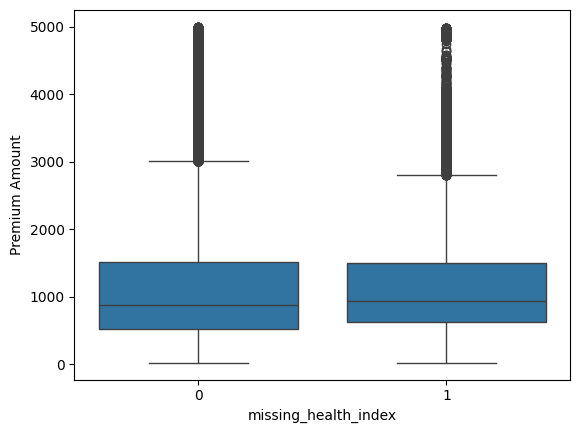

In [9]:
data['missing_health_index'] = data['Health Score'].isna().astype(int)
sns.boxplot(x='missing_health_index', y='Premium Amount', data=data)

REMARKS: If we take a look at above boxplot we can see that the distribution of Missing Health Score is slightly of from Existed Health Score which suggesting the missing values are MAR (Missing at Random) and may correlated to other features. Since the proportion of the data is quite big we can't just drop the NaN. We can't fill the NaN's with simple method either like mean(), median() or interpolate() because it will ruin the distributions. Instead we will use Machine Learning regressor to predict the value of this missing data based on other feature other than target.

---
# CORET-CORETAN

(array([1.7070e+04, 4.1589e+04, 6.0235e+04, 7.4010e+04, 8.5410e+04,
        8.8410e+04, 9.0113e+04, 8.3749e+04, 8.3717e+04, 7.7558e+04,
        7.2376e+04, 6.3848e+04, 5.4530e+04, 4.7483e+04, 4.0306e+04,
        3.3895e+04, 2.7950e+04, 2.3381e+04, 8.1400e+02, 2.4000e+01]),
 array([ 2.01223718,  4.86042103,  7.70860487, 10.55678871, 13.40497256,
        16.2531564 , 19.10134024, 21.94952409, 24.79770793, 27.64589177,
        30.49407562, 33.34225946, 36.19044331, 39.03862715, 41.88681099,
        44.73499484, 47.58317868, 50.43136252, 53.27954637, 56.12773021,
        58.97591405]),
 <BarContainer object of 20 artists>)

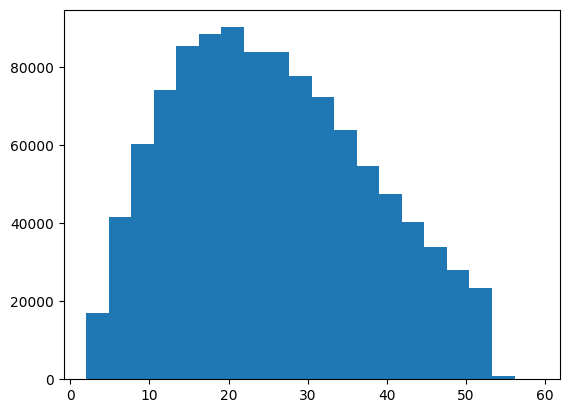

In [39]:
plt.hist(x=a['Health Score'].values, bins=20)

In [24]:
#Columns and values details that will be label encoded (gender udah pasti yah):
print('Education Level: ', data['Education Level'].value_counts().keys())
print('Occupation: ', data['Occupation'].value_counts().keys())

print('Previous Claims: ', data['Previous Claims'].value_counts().keys())

Education Level:  Index(['Master's', 'PhD', 'Bachelor's', 'High School'], dtype='object', name='Education Level')
Occupation:  Index(['Employed', 'Self-Employed', 'Unemployed'], dtype='object', name='Occupation')
Previous Claims:  Index([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0], dtype='float64', name='Previous Claims')


In [42]:
a = data[['Number of Dependents', 'Premium Amount']]
a.dropna(inplace=True)
a

C:\Users\anton\AppData\Local\Temp\ipykernel_29100\4269097646.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a.dropna(inplace=True)


,Number of Dependents,Premium Amount
0,1.0,2869.0
1,3.0,1483.0
2,3.0,567.0
3,2.0,765.0
4,1.0,2022.0
...,...,...
1199992,2.0,1251.0
1199993,1.0,1027.0
1199994,4.0,1584.0
1199995,0.0,1303.0


In [45]:
from sklearn.preprocessing import MinMaxScaler

scale = MinMaxScaler()
a[['Number of Dependents','Premium Amount']] = scale.fit_transform(a[['Number of Dependents','Premium Amount']])
a

C:\Users\anton\AppData\Local\Temp\ipykernel_29100\3191318539.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a[['Number of Dependents','Premium Amount']] = scale.fit_transform(a[['Number of Dependents','Premium Amount']])


,Number of Dependents,Premium Amount
0,0.25,0.572203
1,0.75,0.293834
2,0.75,0.109861
3,0.50,0.149628
4,0.25,0.402089
...,...,...
1199992,0.50,0.247238
1199993,0.25,0.202249
1199994,1.00,0.314119
1199995,0.00,0.257682


In [39]:
import numpy as np

record = np.zeros(shape=(len(a['Number of Dependents']),1))
index_nan = a.loc[a['Number of Dependents'].isnull(), :].index
for i in range(len(record)):
    if i in index_nan: record[i] = 1

a['NA'] = record
a

/data/user/0/ru.iiec.pydroid3/cache/ipykernel_8851/3479980103.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a['NA'] = record


,Number of Dependents,Premium Amount,NA
0,1.0,2869.0,0.0
1,3.0,1483.0,0.0
2,3.0,567.0,0.0
3,2.0,765.0,0.0
4,1.0,2022.0,0.0
...,...,...,...
1199995,0.0,1303.0,0.0
1199996,NaN,821.0,1.0
1199997,0.0,371.0,0.0
1199998,1.0,596.0,0.0


In [12]:
# a = pd.get_dummies(a, columns=['Marital Status'], dummy_na=True)
# a['Age'].fillna(a['Age'].mean(), inplace=True)
# a

/data/user/0/ru.iiec.pydroid3/cache/ipykernel_8851/896076608.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  a['Age'].fillna(a['Age'].mean(), inplace=True)
/data/user/0/ru.iiec.pydroid3/cache/ipykernel_8851/896076608.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a['Age'].fillna(a['Age'].mean(), inplace=True)


,Age,Premium Amount
0,19.0,2869.0
1,39.0,1483.0
2,23.0,567.0
3,21.0,765.0
4,21.0,2022.0
...,...,...
1199995,36.0,1303.0
1199996,54.0,821.0
1199997,19.0,371.0
1199998,55.0,596.0


In [37]:
a.corr(method='spearman')['Premium Amount']

Health Score      0.014875
Premium Amount    1.000000
Name: Premium Amount, dtype: float64

1. initial EDA on Age = -0.002
2. Health Score = 0.016
3. Number of Dependants = -0.001225
4. Credit Score = -0.04
5. 

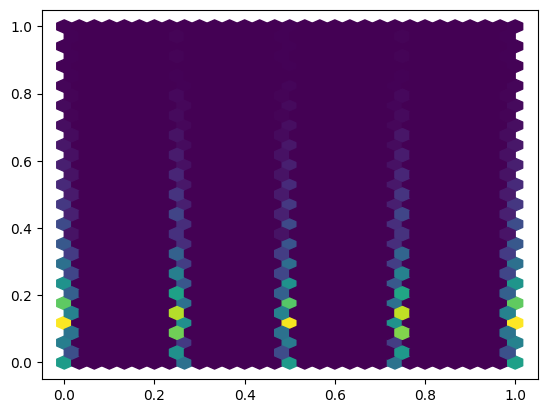

In [46]:
import matplotlib.pyplot as plt
%matplotlib inline
# plt.figure(figsize=(15,5))
# plt.subplot(131)
plt.hexbin(data=a, x='Number of Dependents', y='Premium Amount', gridsize=30, cmap='viridis')

# plt.subplot(132)
# plt.hexbin(data=a, x='Marital Status_Married', y='Premium Amount', gridsize=30, cmap='viridis', vmin=2.0)

# plt.subplot(133)
# plt.hexbin(data=a, x='Marital Status_nan', y='Premium Amount', gridsize=30, cmap='viridis', vmin=2.0)
# plt.tight_layout()
plt.show()
# b = data['Premium Amount'].values[:300000]

# plt.figure(figsize=(10,5))
# plt.hist(b, bins=500)
# plt.show()

In [28]:
data['Age'].value_counts()

Age
53.0    26354
61.0    26218
39.0    26042
64.0    25990
57.0    25971
43.0    25966
62.0    25849
46.0    25756
33.0    25728
47.0    25709
44.0    25642
34.0    25615
58.0    25544
31.0    25500
56.0    25450
32.0    25435
54.0    25370
38.0    25346
36.0    25340
35.0    25323
22.0    25309
59.0    25173
37.0    25163
51.0    25162
55.0    25132
49.0    25107
45.0    25101
20.0    25055
21.0    24987
50.0    24943
40.0    24877
48.0    24834
26.0    24805
24.0    24690
30.0    24683
29.0    24673
19.0    24641
42.0    24626
60.0    24593
52.0    24592
18.0    24488
28.0    24455
63.0    24283
25.0    24221
27.0    24212
41.0    24117
23.0    23225
Name: count, dtype: int64

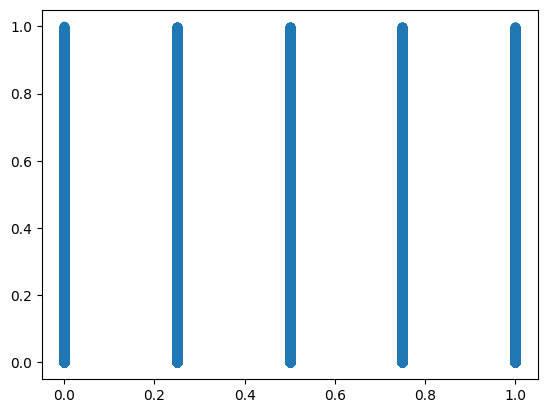

In [49]:
plt.scatter(x=a['Number of Dependents'].values, y=a['Premium Amount'].values)
# plt.bar(x=data['Annual Income'].value_counts().keys(), 
#         height=data['Annual Income'].value_counts().values)
plt.show()

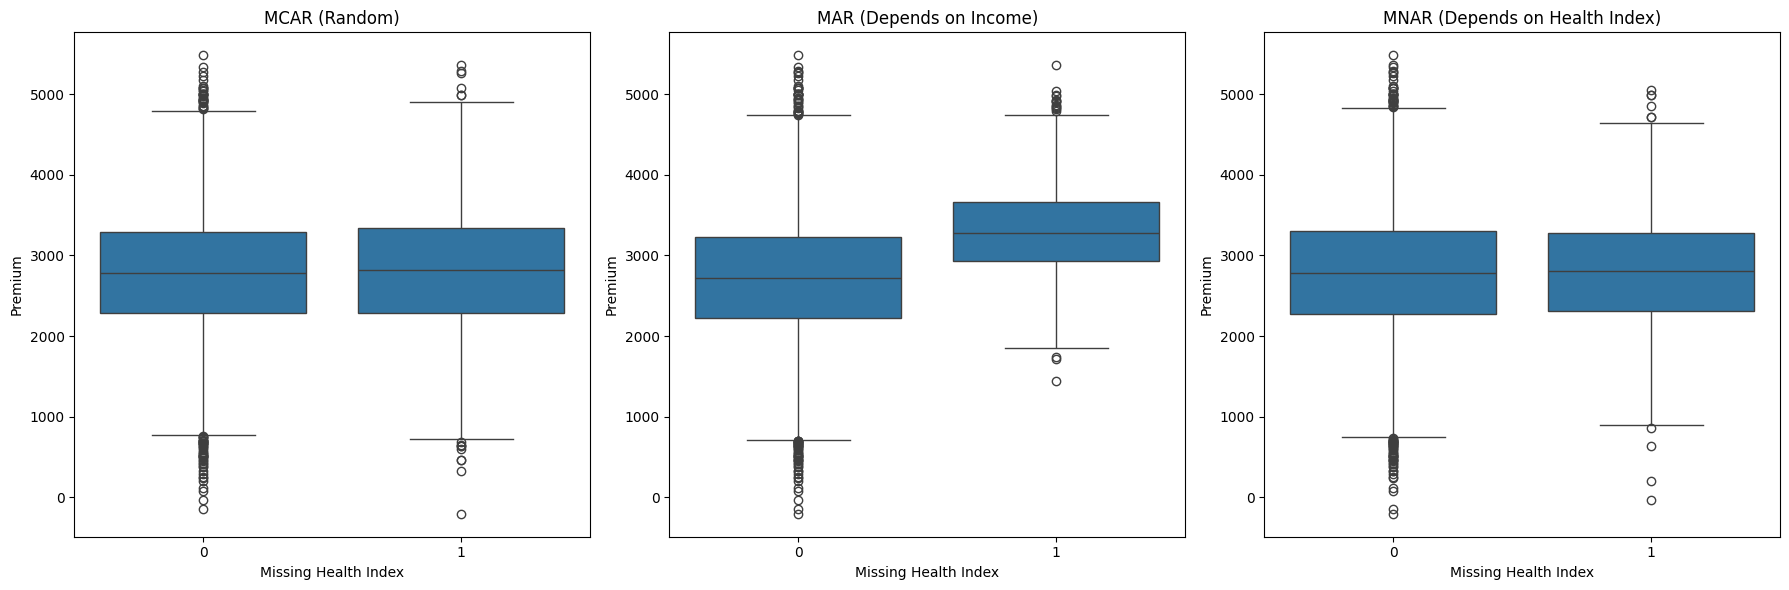

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# Create synthetic dataset
n = 10000
age = np.random.randint(20, 65, size=n)
income = np.random.normal(50000, 15000, size=n)
health_index = np.random.normal(70, 10, size=n)
premium = 500 + 0.05 * income - 3 * health_index + np.random.normal(0, 50, size=n)

df = pd.DataFrame({
    "Age": age,
    "Income": income,
    "Health Index": health_index,
    "Premium": premium
})

# Simulate MCAR: completely random missing values
df_mcar = df.copy()
mask_mcar = np.random.rand(n) < 0.2
df_mcar.loc[mask_mcar, "Health Index"] = np.nan
df_mcar["missing_health_index"] = df_mcar["Health Index"].isna().astype(int)

# Simulate MAR: missingness depends on another observed variable (e.g., Income)
df_mar = df.copy()
prob_mar = 1 / (1 + np.exp(-(df_mar["Income"] - 50000)/5000))  # higher income -> more likely to be missing
mask_mar = np.random.rand(n) < prob_mar * 0.2
df_mar.loc[mask_mar, "Health Index"] = np.nan
df_mar["missing_health_index"] = df_mar["Health Index"].isna().astype(int)

# Simulate MNAR: missingness depends on Health Index itself (unobserved)
df_mnar = df.copy()
prob_mnar = 1 / (1 + np.exp(-(df_mnar["Health Index"] - 70)/5))  # lower health -> more likely to be missing
mask_mnar = np.random.rand(n) < prob_mnar * 0.2
df_mnar.loc[mask_mnar, "Health Index"] = np.nan
df_mnar["missing_health_index"] = df_mnar["Health Index"].isna().astype(int)

# Plot boxplots comparing missingness to Premium
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

for ax, data, title in zip(
    axs,
    [df_mcar, df_mar, df_mnar],
    ["MCAR (Random)", "MAR (Depends on Income)", "MNAR (Depends on Health Index)"]
):
    sns.boxplot(x="missing_health_index", y="Premium", data=data, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Missing Health Index")
    ax.set_ylabel("Premium")

plt.tight_layout()
plt.show()


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error

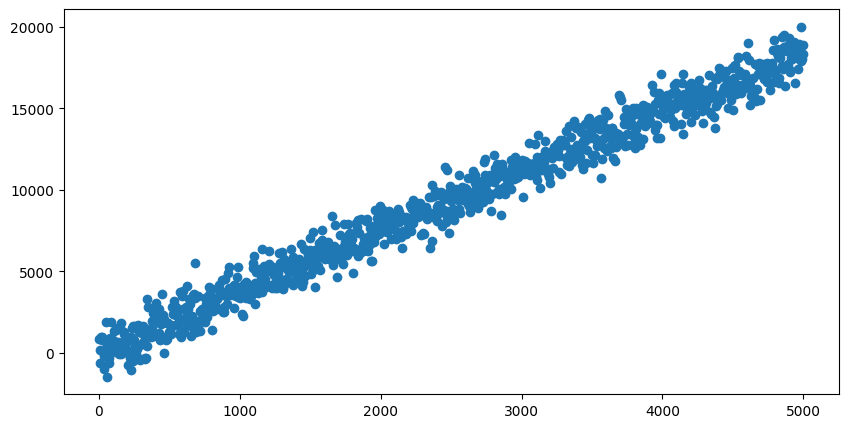

In [2]:
x_lin = np.linspace(0, 5000, 1000)
y_lin = 120.5 + 3.67 * x_lin + np.random.normal(loc=0, scale=826, size=x_lin.shape)

plt.figure(figsize=(10,5))
plt.scatter(x_lin, y_lin)
plt.show()


In [3]:
import pandas as pd

data = pd.DataFrame({
    'input': x_lin,
    'output': y_lin
})

#this one create dataset for training 90% and testing 10%
data_train, data_reserve = train_test_split(data, test_size=0.1, random_state=42)

In [24]:
dataset_a = data_train.loc[(data_train['output'] <= 6670), :]
dataset_b = data_train.loc[(data_train['output'] > 6670) & (data_train['output'] <= 13340), :]
dataset_c = data_train.loc[(data_train['output'] > 13340)]

dataset_a.reset_index(drop=True)
dataset_b.reset_index(drop=True)
dataset_c.reset_index(drop=True)

,input,output
0,4684.684685,17774.501922
1,4799.799800,17027.155063
2,4589.589590,18205.715018
3,4119.119119,15466.827126
4,4929.929930,18879.878698
...,...,...
251,4029.029029,15804.923870
252,3848.848849,14807.878906
253,3318.318318,13589.466336
254,4359.359359,15926.471842


In [25]:
round(y_lin.max())

20009

In [26]:
model_bins = {}
def machineLearningTrain(datasets):
    x_subset = datasets[['input']]
    y_subset = datasets[['output']]

    x_train_sub, x_test_sub, y_train_sub, y_test_sub = train_test_split(x_subset, y_subset, test_size=0.3, random_state=42)

    print(f'Testing model in progress.')
    lin_reg = LinearRegression()
    lin_reg.fit(x_train_sub, y_train_sub)
    y_pred_sub = lin_reg.predict(x_test_sub)

    print('Here are the machine learning testing result: ')
    rmse_score = root_mean_squared_error(y_test_sub, y_pred_sub)
    mape_score = mean_absolute_percentage_error(y_test_sub, y_pred_sub)
    print(f'rmse_score: {rmse_score}, mape_score is: {mape_score}')

    range_set = str(round(datasets['output'].min())) + '-' + str(round(datasets['output'].max()))
    print(f'Inserting database {range_set} into dictionaries.')
    model_bins[range_set] = lin_reg
    print('Succesfully add model to dictionaries.')

machineLearningTrain(dataset_a)
machineLearningTrain(dataset_b)
machineLearningTrain(dataset_c)

center_A = np.mean(dataset_a['input'], axis=0)
center_B = np.mean(dataset_b['input'], axis=0)
center_C = np.mean(dataset_c['input'], axis=0)

center_masses = np.array([center_A, center_B, center_C]).reshape(-1,1)  # shape (3, n_features)
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(center_masses, [0, 1, 2])

Testing model in progress.
Here are the machine learning testing result: 
rmse_score: 833.766992670105, mape_score is: 0.7985394861310043
Inserting database -1458-6659 into dictionaries.
Succesfully add model to dictionaries.
Testing model in progress.
Here are the machine learning testing result: 
rmse_score: 661.8237347375066, mape_score is: 0.05460500853756969
Inserting database 6704-13309 into dictionaries.
Succesfully add model to dictionaries.
Testing model in progress.
Here are the machine learning testing result: 
rmse_score: 824.2212113988655, mape_score is: 0.03945474665105415
Inserting database 13377-20009 into dictionaries.
Succesfully add model to dictionaries.


KNeighborsClassifier(n_neighbors=1)

In [27]:
data_reserve.reset_index(drop=True, inplace=True)
data_reserve.head(35)

,input,output
0,2607.607608,9919.918259
1,3688.688689,13367.530924
2,3703.703704,15495.331656
3,3303.303303,12775.229486
4,2057.057057,8022.759697
5,3393.393393,12774.970421
6,3133.133133,10123.454193
7,2567.567568,9811.645928
8,4299.299299,16123.273599
9,680.680681,5500.610510


In [30]:
model_bins

{'-1458-6659': LinearRegression(),
 '6704-13309': LinearRegression(),
 '13377-20009': LinearRegression()}

In [36]:
model_test = model_bins['6704-13309']
incoming_sample = data_reserve.iloc[31,0].reshape(-1,1)

test_pred = model_test.predict(incoming_sample)
closest_model_id = knn.predict(incoming_sample)
distances = knn.kneighbors(incoming_sample, return_distance=True)
print(distances)
print(test_pred)

(array([[205.77003336]]), array([[0]], dtype=int64))
[[3801.66796485]]


c:\Programming\.vscode\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
test_result = []
def testingLimit(incoming):
    for k in model_bins.values:
        refine_scaled = scaler.transform(incoming)
        test_pred = k.predict(incoming)
        closest_model_id = knn.predict(refine_scaled)
        distances = knn.kneighbors(refine_scaled, return_distance=False)
        test_result.append((test_pred, distances))

for i in range(len(test_result)):
    if i[0] >= boundary_low or i[0] <= boundary_upper and i[1] == i:
        #proceed to staging second level
        new_low_limit = i * 1250
        
    else: #in the extreme edge cases






incoming_sample = data_mock_train.drop(columns='Premium Amount')
refine = incoming_sample.iloc[[18], :]